In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

Scenario:\
The medical aid scheme needs help speeding up their ability to apply their dreaded disease benefits to customers who need it. They want to start with cancer, and in this case, have asked that you source your own cancer-related dataset to conduct basic analysis, train a classification algorithm.

- GitHub Repository: https://github.com/EMGPSD/pdan8411-g1-2026-part2-st10302391.git
- Cancer Risk Factors Dataset: https://www.kaggle.com/datasets/tarekmasryo/cancer-risk-factors-dataset

In [2]:
df = pd.read_csv("OneDrive/Documents/PDD1/Prog for Data Analytics/cancer-risk-factors.csv")

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
df.head()

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,7,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,7,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,4,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,4,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,10,9,10,9,0,0,5,0.524358,25.1,2,Medium


# 1. Exploratory Data Analysis 
The EDA has been split into three main sections in order to understand the nature of the dataset:
1. Basic Information
2. Univariate analysis
3. Bivariate analysis
4. Multivariate analysis

## 1.1 Dataset Information
First and foremost, this dataset contains two target variables; "Cancer_Type" and "Risk_Level". The goal of this project is for the insurance company to predict clients' risk for cancer for their dreaded diseases programme, so the target is Risk_Level (low/ medium/ high).

Cancer_Type will be removed from the dataset so it does not influence the predictions or increase the scope of the project.

---

This section will cover the following:
- The dataset's structure using the info() method - this will also tell us if there are any null values
- A statistical summary of the variables in the dataset using the describe() method
- Then there will be a check for duplicates 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   object 
 1   Cancer_Type              2000 non-null   object 
 2   Age                      2000 non-null   int64  
 3   Gender                   2000 non-null   int64  
 4   Smoking                  2000 non-null   int64  
 5   Alcohol_Use              2000 non-null   int64  
 6   Obesity                  2000 non-null   int64  
 7   Family_History           2000 non-null   int64  
 8   Diet_Red_Meat            2000 non-null   int64  
 9   Diet_Salted_Processed    2000 non-null   int64  
 10  Fruit_Veg_Intake         2000 non-null   int64  
 11  Physical_Activity        2000 non-null   int64  
 12  Air_Pollution            2000 non-null   int64  
 13  Occupational_Hazards     2000 non-null   int64  
 14  BRCA_Mutation           

What we know about the dataset now:
- There are 2000 total observations and 21 columns
- Primary keys (PatientID) are not relevant, it will be removed
- There are 18 features and 2 targets
- The chosen target variable (Risk_Level) is categorical -> ordinal
- All other features are numerical (int/ float)
- There are no null values

In [5]:
df.describe()

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.00000,2000.000000,2000.000000,2000.000000
mean,63.248000,0.489000,5.157000,5.035000,5.967500,0.194500,5.189500,4.563500,4.927500,4.015000,5.323000,4.979000,0.032500,0.19650,3.94050,0.454449,26.183350,4.938500
std,10.462946,0.500004,3.325339,3.260996,3.061393,0.395914,3.154452,3.088323,3.045305,2.978458,3.207462,3.212899,0.177368,0.39745,3.04887,0.123074,3.947459,3.166027
min,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.029285,15.000000,0.000000
25%,56.000000,0.000000,2.000000,2.000000,4.000000,0.000000,3.000000,2.000000,3.000000,1.000000,3.000000,2.000000,0.000000,0.00000,1.00000,0.366982,23.500000,2.000000
50%,64.000000,0.000000,5.000000,5.000000,6.000000,0.000000,5.000000,4.000000,5.000000,4.000000,5.000000,5.000000,0.000000,0.00000,4.00000,0.455399,26.200000,5.000000
75%,70.000000,1.000000,8.000000,8.000000,9.000000,0.000000,8.000000,7.000000,8.000000,6.000000,8.000000,8.000000,0.000000,0.00000,6.00000,0.539782,28.700000,8.000000
max,90.000000,1.000000,10.000000,10.000000,10.000000,1.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,1.00000,10.00000,0.852158,41.400000,10.000000


What we can tell about some of the data so far:

Most of the variables (smoking, alcohol use, obesity, etc) are on a scale of 0-10. The minimum is 0 and the maximum is 10. The means for these variables all around 4-6.

Some of the variables are binary (gender, family history, BRCA mutation, H Pylori Infection). The minimum is 0 and the maximum is 1.

The mean for gender is 0.49, very balanced. The mean for family history is 0.19, which quite imbalanced - very few people hvae a family history of cancer.
The mean for BRCA mutation is 0.03 which is also highly imbalanced 

The range for age is from 25 to 90, mean is 63.25, while the median is 64. This shows that most of the patients are older, the distribution is farily distributed (around 60) and there are no extreme outliers

The BMI statistics show that that most people are slightly overweight (mean is 26.18).

Underweight: BMI less than 18.5 |
Healthy weight: BMI 18.5–24.9 |
Overweight: BMI 25–29.9 |
Obese: BMI 30 or higher (Kumar, 2025)

In [6]:
# checking for duplicates 
print(f"Duplicates present? {df.duplicated().any()}")
print(f"Number of duplicates: {df.duplicated().sum()}")

Duplicates present? False
Number of duplicates: 0


There are no duplicates, so no corrective action needs to be taken.

### Removing irrelevant fields
Cancer_Type and Patient_ID are not needed - they would get in the way of the EDA.\
Now there are only 19 columns

In [7]:
# remove patient ID and cancer type
df.drop(["Patient_ID", "Cancer_Type"], axis = 1, inplace = True)

In [8]:
df.shape

(2000, 19)

In [9]:
# colours
palette = sns.color_palette("flare", 6)
colours = [palette[2], palette[0], palette[5]] # for pie chart
colourSet = {"Low": palette[0], "Medium": palette[2], "High": palette[5]} # for bar graphs

## 1.2 Univariate Analysis
Univariate analysis was done to examine the distribution of target variable (risk level) (GeeksforGeeks, 2022b). This helps identify class imbalance, which can reduce the model’s ability to correctly identify high risk cases.\
This can be addressed using class weighting and bootstrapping

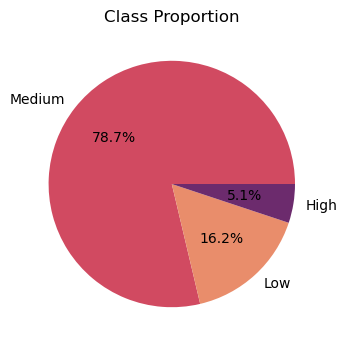

In [10]:
.

The class imbalance is quite severe, especially for "High" risk.
- 1574 Medium risk cases
- 324 Low risk cases
- 102 High risk cases

The model would become biased towards predicting medium risk while performing poorly for high risk cases.\
If the model underperforms here, genuinely high risk clients could be missed - this is a problem because high risk clients need the dreaded disease benefits support the most 

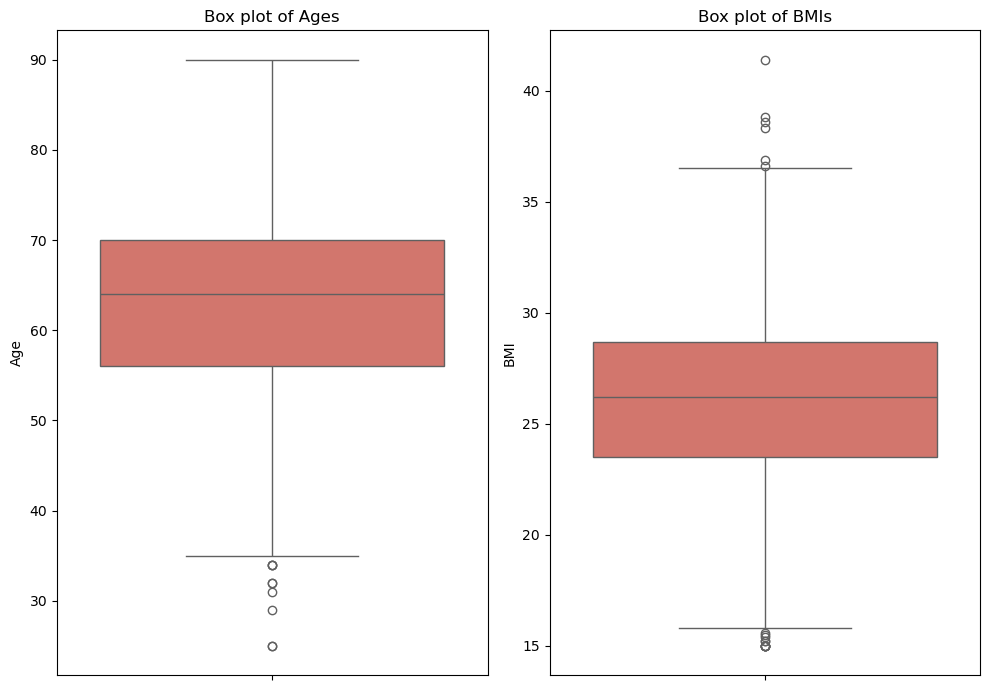

In [11]:
# visualise distribution of age and BMI in box plot to identify any outliers
fig, axes = plt.subplots(1,2, figsize=(10, 7))
axes = axes.flatten()
sns.boxplot(df["Age"], ax=axes[0], color=palette[1])
axes[0].set_title("Box plot of Ages")

sns.boxplot(df["BMI"], ax=axes[1], color=palette[1])
axes[1].set_title("Box plot of BMIs")

plt.tight_layout()
plt.show()

There are outliers in both Age and BMI\
they are not erroneous or impossible -> Random Forest is able to handle outliers, there is no need for removal or transformation

## 1.3 Bivariate Analysis
Bivariate analysis was done to look at the relationship between each feature and the target variable. This helps identify which features are strongly linked to cancer risk and can inform feature selection.

Since there is severe class imbalance, the **mean score/ value per class** was calculated and visualised in bar graphs to observe the trends and associations between features and the different cancer risk levels

In [12]:
means = df.groupby("Risk_Level").mean(numeric_only=True)
# print(means)

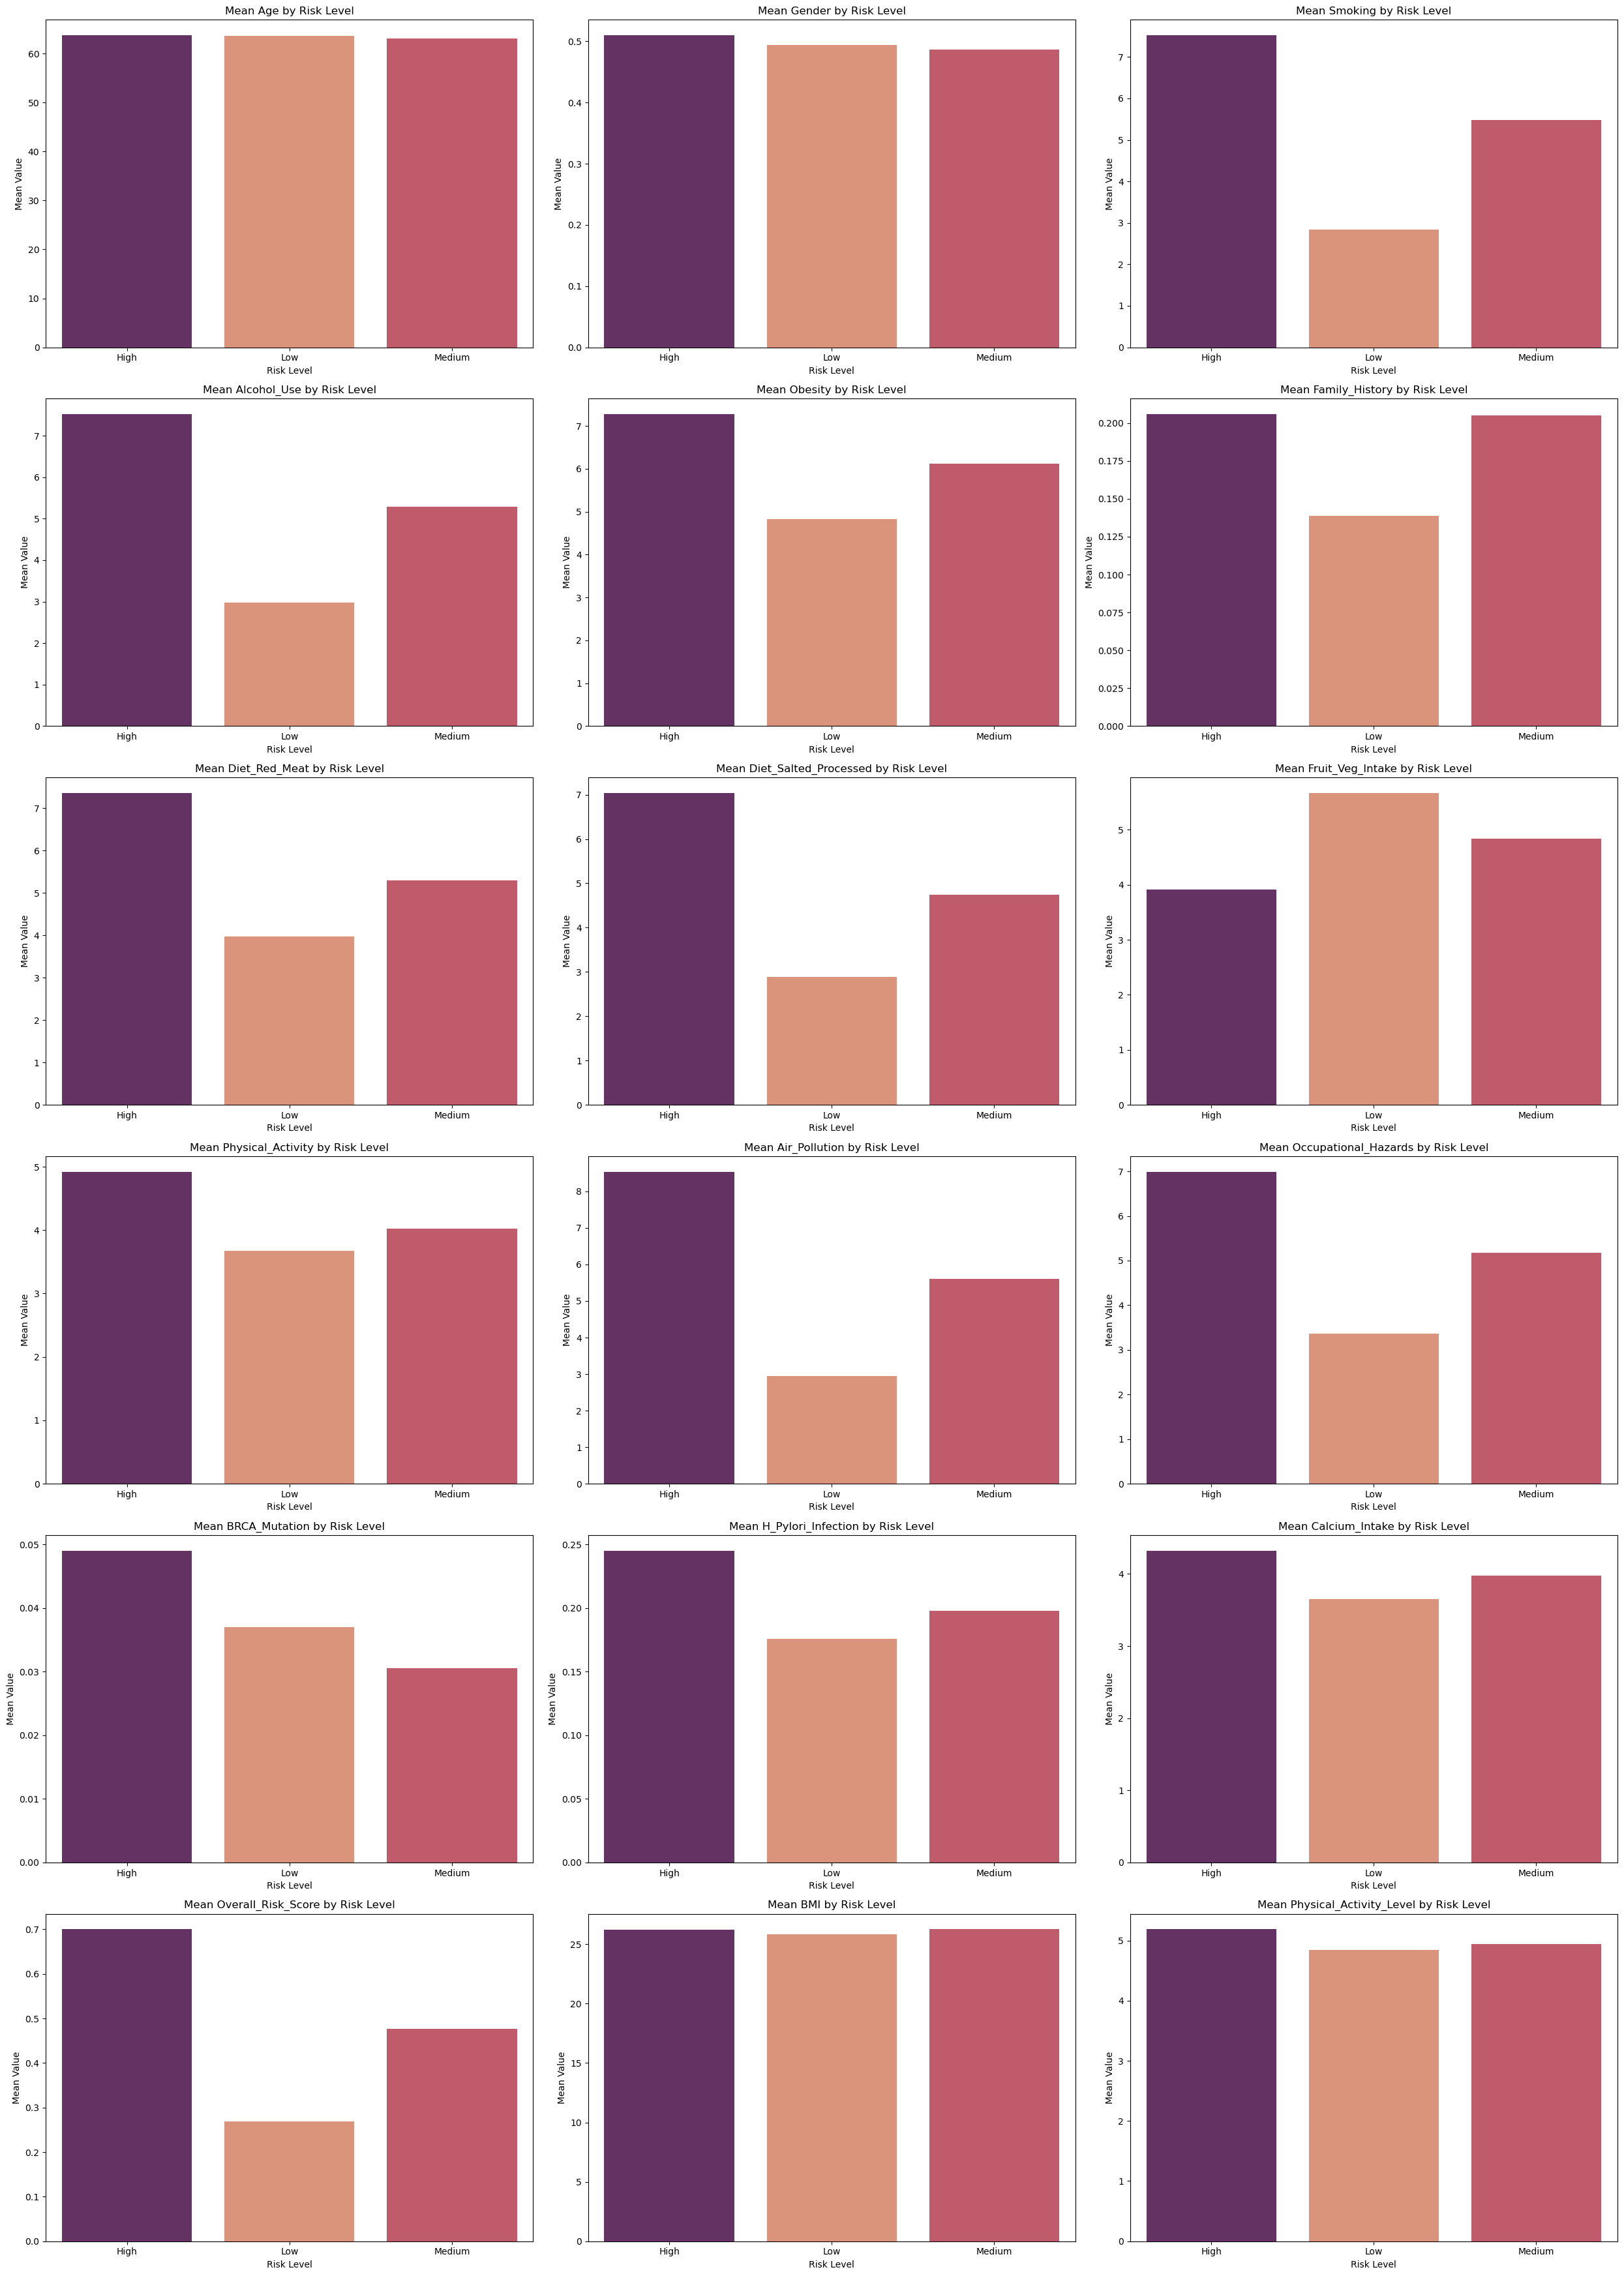

In [13]:
fig, axes = plt.subplots(6, 3, figsize=(25, 35))
axes = axes.flatten()

for i, feature in enumerate(means.columns):
    sns.barplot(x=means.index,y=means[feature].values, ax=axes[i], hue=means.index, palette=colourSet, legend=False)

    axes[i].set_title(f"Mean {feature} by Risk Level")
    axes[i].set_ylabel("Mean Value")
    axes[i].set_xlabel("Risk Level")

plt.tight_layout()
plt.show()

Smoking is a good indicator of risk level -> **high risk people are heavy smokers** - heavy smoking increases cancer risk\
The same trend is observed for many other features like alcohol use, obesity, red meat consumption, salted and processed food consumption, physical activity and air pollution etc.\
The average smoking frequency/level for:
- High risk: 7.52
- Medium risk: 5.48
- Low risk: 2.85

The opposite is true for fruit and vegetable intake -> higher fruit and vegetable consumption is associated with lower cancer risk.\
Average fruit and vegetable intake for:
- High risk: 3.91
- Medium risk: 4.84
- Low risk: 5.67

Note: there are two variables related to physical activity; “Physical_Activity” and “Physical_Activity_Level”. One of the two will be removed based on analysis of feature importance later.

### Encoding
Risk level is categorical - must be encoded into numerical form so further analysis can be conducted\
0 = Low | 1 = Medium | 2 = High

In [14]:
df["Risk_Level"] = df["Risk_Level"].map({"Low": 0, "Medium": 1, "High": 2})
df.head()

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,68,0,7,2,8,0,5,3,7,4,6,3,1,0,0,0.398696,28.0,5,1
1,74,1,8,9,8,0,0,3,7,1,3,3,0,0,5,0.424299,25.4,9,1
2,55,1,7,10,7,0,3,3,4,1,8,10,0,0,6,0.605082,28.6,2,1
3,61,0,6,2,2,0,6,2,4,6,4,8,0,0,8,0.318449,32.1,7,0
4,67,1,10,7,4,0,6,3,10,9,10,9,0,0,5,0.524358,25.1,2,1


### Correlation Analysis
Correlation represents the strength and direction of the relationship between two variables.\
Almost all the variables have a weak postive correlation (r < 0.5) with cancer risk which means as the feature value increases, so does cancer risk.\
This is not the case for age and fruit and vegetable intake. This means higher fruit and vegetable intake lowers cancer risk (as shown in the bar graph earlier). Gender has almost no correlation with risk.

(Ignoring Overall_Risk_Score) Air pollution and smoking are the strongest predictors although the correlations are weak.

In [15]:
correlations = df.corr()["Risk_Level"].drop("Risk_Level")
df_corr = pd.DataFrame({"Correlation": correlations.sort_values(ascending=False)})
df_corr

,Correlation
Overall_Risk_Score,0.770886
Air_Pollution,0.382078
Smoking,0.332325
Alcohol_Use,0.314204
Diet_Salted_Processed,0.287425
Occupational_Hazards,0.253083
Diet_Red_Meat,0.218038
Obesity,0.183719
Physical_Activity,0.076589
Family_History,0.054082


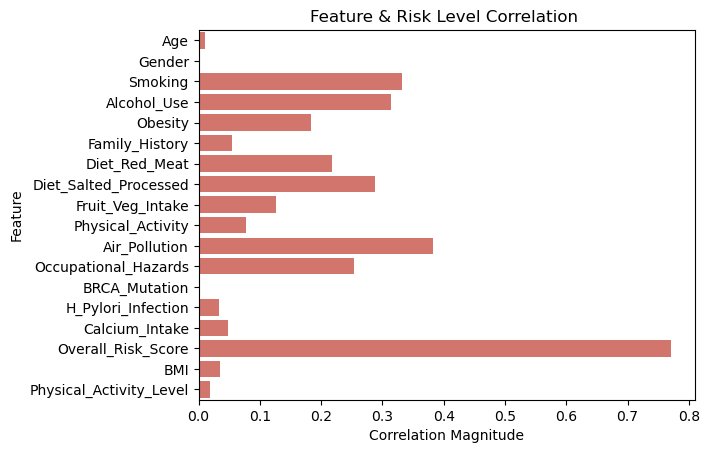

In [16]:
# plotting the |r| to get the strength only
sns.barplot(x=correlations.abs(), y=correlations.index, color=palette[1], orient="h")
plt.title("Feature & Risk Level Correlation ")
plt.ylabel("Feature")
plt.xlabel("Correlation Magnitude")
plt.show()

## 1.4 Multivariate Analysis
Multivariate analysis was done to examine the relationships between all independent variables simultaneously. This helps identify interactions and correlations and also contributes towards feature selection.\
There are no strongly correlated features, all are weak to moderate (0 <= r <= 0.5)

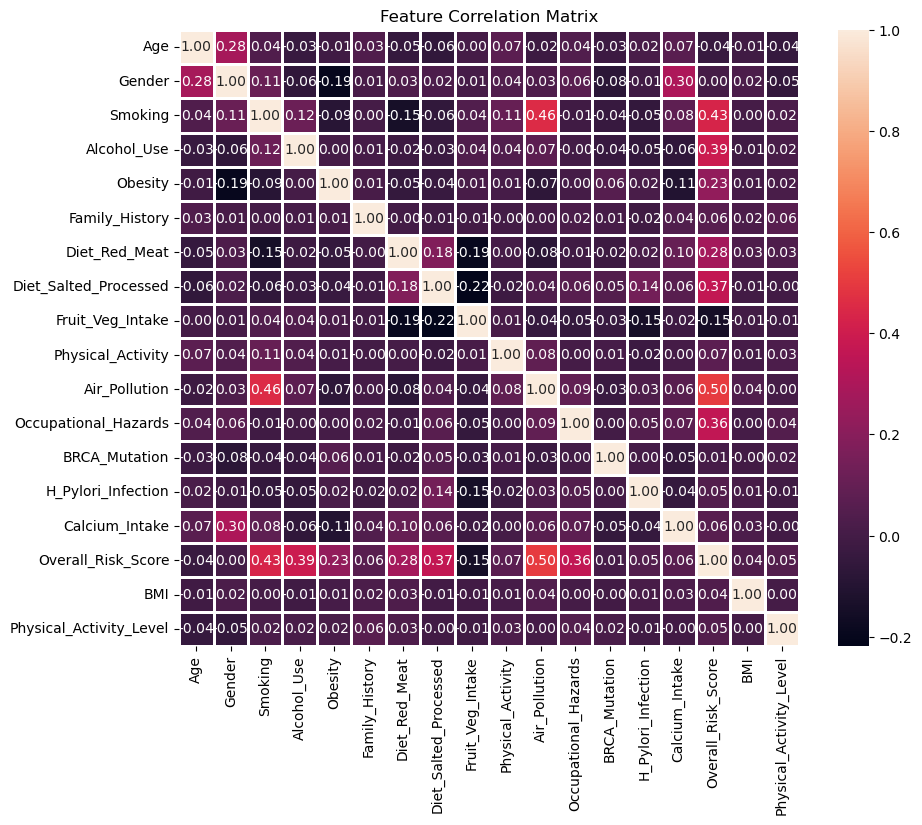

In [17]:
df_corr = df.drop("Risk_Level", axis=1)

plt.figure(figsize=(10,8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', linewidth=2)
plt.title("Feature Correlation Matrix")
plt.show()

---
# 2. Feature Selection
Patient_ID and Cancer_Type were already removed\
Overall_Risk_Score will be removed -> target variable is based on this value, and letting the model know the risk score lets it take a shortcut to predicting the outcomes.

In [18]:
df.drop("Overall_Risk_Score", axis=1, inplace=True)

The [correlation analysis](#Correlation-Analysis) done earlier could inform feature selection by filtering out those that have very weak correlations with the target variable.However, all the features are very weakly correlated with the target.\
Two other techniques were used to decide the final feature set: **Gini Importance** and **Permutation Feature Importance**.

The features that most consistently appeared in the bottom 5 for all three techniques were removed.

## 2.1 Correlations (Magnitude)
The correlations in the bivariate analysis included the direction of the relationship. So this will show only the magnitudes for comparison with the other methods

In [19]:
correlations = df.corr()["Risk_Level"].drop("Risk_Level")
df_corr = pd.DataFrame({"Correlation": correlations.abs().sort_values(ascending=False)}) # to get |r|
df_corr

,Correlation
Air_Pollution,0.382078
Smoking,0.332325
Alcohol_Use,0.314204
Diet_Salted_Processed,0.287425
Occupational_Hazards,0.253083
Diet_Red_Meat,0.218038
Obesity,0.183719
Fruit_Veg_Intake,0.125780
Physical_Activity,0.076589
Family_History,0.054082


## 2.2 Gini Importance
Random Forest has inherent feature importance which can be derived from gini impurity by getting the total reduction in impurity that each feature contributes across all splits (GeeksforGeeks, 2024b).\
The features can then be ranked based on their predictive power to aid feature selection.

In [20]:
X = df.drop("Risk_Level", axis = 1)
y = df["Risk_Level"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

In [22]:
rfc = RandomForestClassifier(class_weight= "balanced", n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
# calculate GINI score (GeeksforGeeks, 2024b)
importances = rfc.feature_importances_
df_gini = pd.DataFrame({"Feature": X.columns, "Gini Importance": importances}).sort_values("Gini Importance", ascending = False)
df_gini

,Feature,Gini Importance
10,Air_Pollution,0.169711
2,Smoking,0.131447
3,Alcohol_Use,0.131337
7,Diet_Salted_Processed,0.097383
6,Diet_Red_Meat,0.078746
11,Occupational_Hazards,0.078573
4,Obesity,0.072253
15,BMI,0.044608
0,Age,0.040562
8,Fruit_Veg_Intake,0.037742


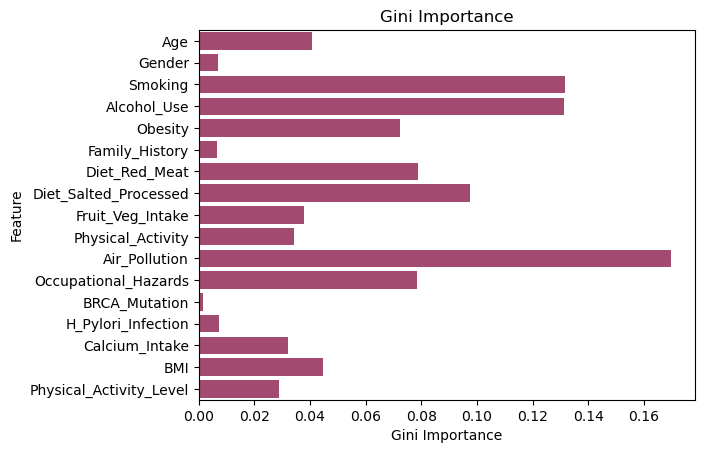

In [24]:
sns.barplot(x=importances, y=X.columns, color=palette[3], orient="h")
plt.title("Gini Importance")
plt.ylabel("Feature")
plt.xlabel("Gini Importance")
plt.show()

BRCA Mutation, Family History, Gender, H Pylori Infection, Physical Activity Level are the weakest predictors.

## 2.3 Permutation Feature Importance
Measures importance by shuffling each feature, this is more robust than Gini importance because it does not depend on the inner workings of the model (GeeksforGeeks, 2024b)

In [25]:
pi_result = permutation_importance(rfc, X_test, y_test, n_repeats = 10, random_state=0, n_jobs = -1) 
# (GeeksforGeeks, 2024b)

In [26]:
pm_df = pd.DataFrame({"Feature": X.columns, "P.I.": pi_result.importances_mean}).sort_values("P.I.", ascending=False)
pm_df["P.I."] = pm_df["P.I."].round(4)
pm_df

,Feature,P.I.
3,Alcohol_Use,0.0265
7,Diet_Salted_Processed,0.0245
6,Diet_Red_Meat,0.0195
2,Smoking,0.0192
11,Occupational_Hazards,0.0172
10,Air_Pollution,0.0165
5,Family_History,0.0087
8,Fruit_Veg_Intake,0.0085
0,Age,0.0067
9,Physical_Activity,0.0062


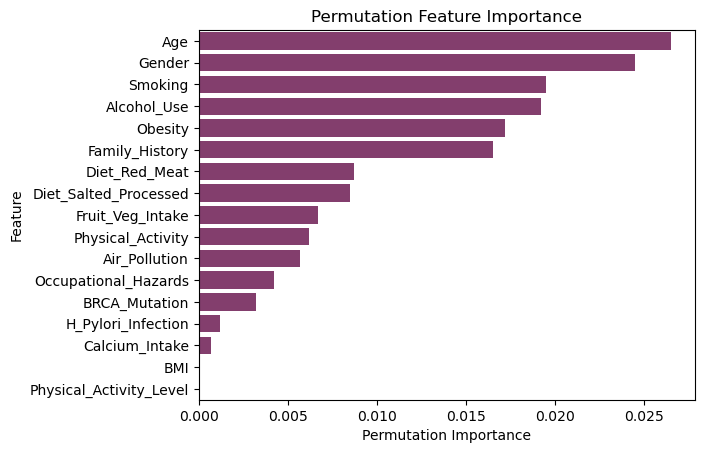

In [27]:
sns.barplot(y=X.columns, x=pm_df["P.I."], color=palette[4],orient="h")
plt.title("Permutation Feature Importance")
plt.ylabel("Feature")
plt.xlabel("Permutation Importance")
plt.show()

## 2.4 Final Selection  
The features that appeared in the bottom 5 most consistently were Gender, BRCA Mutation, H Pylori Infection, Calcium Intake and Physical Activity Level. These features will be removed.

In [28]:
# new data frame for final feature set
data = df.drop(["BRCA_Mutation", "Gender", "Calcium_Intake", "H_Pylori_Infection", "Physical_Activity_Level"], axis = 1)

In [29]:
data.shape

(2000, 13)

There are now 13 columns -> 12 features + target

In [30]:
data.head()

,Age,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BMI,Risk_Level
0,68,7,2,8,0,5,3,7,4,6,3,28.0,1
1,74,8,9,8,0,0,3,7,1,3,3,25.4,1
2,55,7,10,7,0,3,3,4,1,8,10,28.6,1
3,61,6,2,2,0,6,2,4,6,4,8,32.1,0
4,67,10,7,4,0,6,3,10,9,10,9,25.1,1


---
# 3. Model Training
All models will have ``class_weight="balanced_subsample"`` (GeeksforGeeks, 2024a)
## 3.1 Splitting
Split data into features (X) and labels (y)\
Used stratified train-test split (80% training, 20% testing) to maintain class distribution\
(Scaling was not done since it has little to no effect on RF)

In [31]:
X = data.drop("Risk_Level", axis = 1)
y = data["Risk_Level"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state = 42)

## 3.2 Model 1 - Default Random Forest
Fit an RF model with the default parameters (class weighting applied)

In [33]:
# (Taufiq, 2024)
model = RandomForestClassifier(class_weight="balanced_subsample", random_state=42) 

In [34]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_pred = model.predict(X_test)

## 3.3 Model 2 - Hyperparameter Tuning
Use RandomizedSearchCV hyperparameter tuning method to find the best hyperparameters

In [36]:
# (GeeksforGeeks, 2022a)
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

In [37]:
# (GeeksforGeeks, 2022a)
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid, scoring="f1_weighted", n_iter=48, cv=5, verbose=2, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,n_iter,48
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [38]:
print(f"The Best Hyperparameters:\n{random_search.best_params_}")

The Best Hyperparameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30, 'criterion': 'entropy', 'bootstrap': True}


In [39]:
best_model = random_search.best_estimator_

In [40]:
y_pred_best = best_model.predict(X_test)

## 3.4 Model 3 - Balanced Random Forest
Balanced RF does undersampling on the majority class so that each tree uses a balanced dataset between the majority and minority classes instead of using the imbalanced dataset (Taufiq, 2024)

In [41]:
balanced_model = BalancedRandomForestClassifier(class_weight="balanced_subsample", random_state=42)

In [42]:
balanced_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [43]:
y_pred_balanced = balanced_model.predict(X_test)

---
# 4. Model Evaluation
Model Evaluation was done using:
- Stratified KFold Cross Validation (F1-macro)
- Precision, Recall, F1-score
- Confusion Matrix

Note: the evaluation will focus mostly on how the models handled the High risk class.\
Recall was prioritised for the high-risk class because dreaded diseases benefits is more urgent to those at high risk.

## 4.1 Stratified KFold Cross Validation
Since the dataset is highly imbalanced, this method maintains the proportion of each risk level in every fold, ensuring a more reliable evaluation of the model's performance.

"F1_macro" was used because it assesses the performance equally across all risk levels
- because it prevents the majority class from dominating the evaluation and
- ensures performance on the minority class is equally considered.
(Leung, 2022)

In [44]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 4.1.1 Default Model CV

In [45]:
def_scores = cross_val_score(model, X, y, cv=skf, scoring="f1_macro")
avg_def = def_scores.mean().round(3) # so i can use it later
print("Scores for Default Model: ", def_scores)
print("Mean score:", avg_def)

Scores for Default Model:  [0.52211243 0.55713808 0.59215159 0.54167388 0.56610752]
Mean score: 0.556


### 4.1.2 Tuned Model CV

In [46]:
best_scores = cross_val_score(best_model, X, y, cv=skf, scoring="f1_macro")
avg_best = best_scores.mean().round(3) 
print("Scores for Tuned Model: ", best_scores)
print("Mean score:", avg_best)

Scores for Tuned Model:  [0.66931171 0.66299465 0.71562378 0.60514421 0.72852428]
Mean score: 0.676


### 4.1.3 Balanced Model CV

In [47]:
balanced_scores = cross_val_score(balanced_model, X, y, cv=skf, scoring="f1_macro")
avg_balanced = balanced_scores.mean().round(3)
print("Scores for Balanced Model: ", balanced_scores)
print("Mean score:", avg_balanced)

Scores for Balanced Model:  [0.75732005 0.59682547 0.65073398 0.67368742 0.66790069]
Mean score: 0.669




## 4.2 Classification Report
- Recall measures the model's ability to correctly identify the minority class (High risk)
- Precision evaluates how many predicted instances of a class are correct
- F1-score combines precision and recall -> suitable for evaluating the performance across all the classes

### 4.2.1 Default Model Report

In [48]:
print("Classification Report for Default Model:")
print(classification_report(y_test, y_pred))

Classification Report for Default Model:
              precision    recall  f1-score   support

           0       0.83      0.45      0.58        65
           1       0.85      0.97      0.91       315
           2       0.60      0.15      0.24        20

    accuracy                           0.85       400
   macro avg       0.76      0.52      0.58       400
weighted avg       0.84      0.85      0.82       400



### 4.2.2 Tuned Model Report

In [49]:
print("Classification Report for Tuned Model:")
print(classification_report(y_test, y_pred_best))

Classification Report for Tuned Model:
              precision    recall  f1-score   support

           0       0.75      0.65      0.69        65
           1       0.90      0.94      0.92       315
           2       0.67      0.50      0.57        20

    accuracy                           0.87       400
   macro avg       0.77      0.70      0.73       400
weighted avg       0.86      0.87      0.87       400



### 4.2.3 Balanced Model Report

In [50]:
print("Classification Report for Balanced Model:")
print(classification_report(y_test, y_pred_balanced))

Classification Report for Balanced Model:
              precision    recall  f1-score   support

           0       0.54      0.82      0.65        65
           1       0.93      0.77      0.85       315
           2       0.36      0.75      0.48        20

    accuracy                           0.78       400
   macro avg       0.61      0.78      0.66       400
weighted avg       0.84      0.78      0.80       400



## 4.3 Confusion Matrices
The confusion matrix shows the number of correct and incorrect predictions made for each risk level.\
The diagonal values show the correctly classified instances while the non-diagonals show the missclassifications.

How the model performed on the high risk class is the most important.

### 4.3.1 Default Model CM

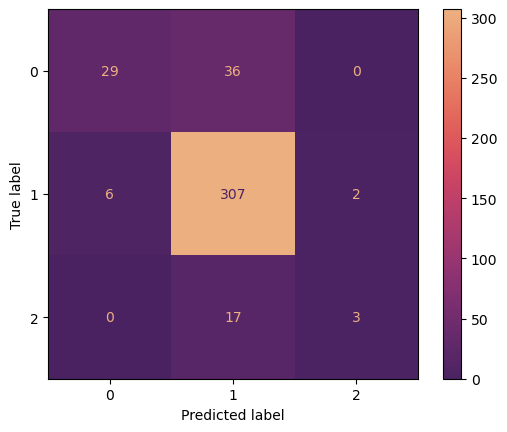

In [51]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="flare_r")

### 4.3.2 Tuned Model CM

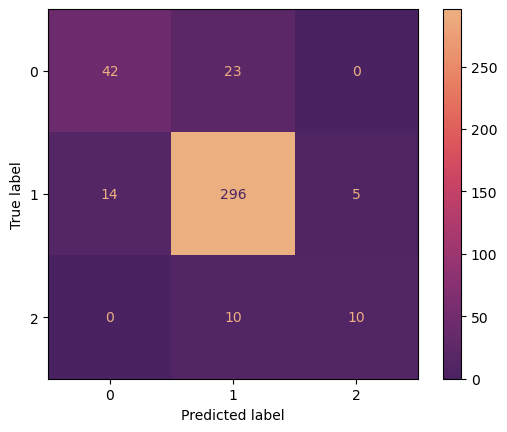

In [52]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, cmap="flare_r")

### 4.3.3 Balanced Model CM

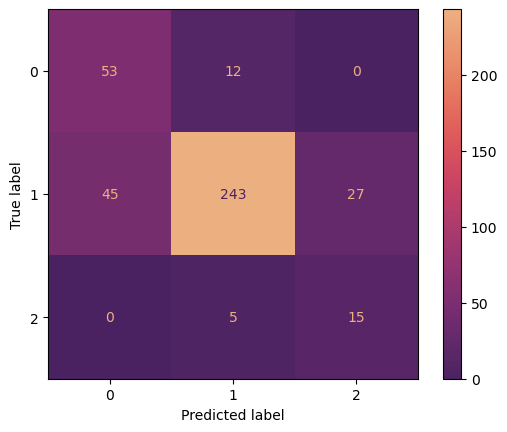

In [53]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced, cmap="flare_r")

## 4.4 Evaluation Conclusions
The tuned model has the best highest accuracy, overall performance and handled the high risk class better than the default.\
The balanced RF model provided better performance in terms of recall and correct identification of the minority class.

Trade-off between predictive performance and minority class sensitivity.\
Since the primary goal is to correctly detect high risk individuals in the imbalanced datatset, the Balanced Random Forest model is the most appropriate choice despite its low accuracy

Overall:
- The tuned model has the best statistical performance
- The balanced RF model is best for detecting high risk cases

Table below shows:
- Recall on "High" risk
- F1 score on "High" risk
- Number of correctly classified High risk cases
- Overall F1_macro score from cross validation

In [54]:
df_highEvaluation = pd.DataFrame({
    "Recall (H)": [0.15, 0.50, 0.75],
    "F1 Score (H)": [0.24, 0.57, 0.48],
    "Correct H": [3, 10, 15],
    "Overall F1_macro": [0.56, 0.68, 0.67]
}, index=["Default RF", "Tuned RF", "Balanced RF"])

df_highEvaluation

,Recall (H),F1 Score (H),Correct H,Overall F1_macro
Default RF,0.15,0.24,3,0.56
Tuned RF,0.50,0.57,10,0.68
Balanced RF,0.75,0.48,15,0.67


---
# 5. Model Improvement Attempts
(Other than implementing Balanced RF)

## 5.1 Retraining with SMOTE
The models will be retrained with oversampled data (using SMOTE) to see if their performance is improved when the dataset is balanced out

Results:\
The models (default and tuned) performed better on the high risk class after being trained on SMOTE oversampled data than on the original data.\
They did not do better than the balanced RF model however.

In [55]:
# (GeeksforGeeks, 2024d)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

In [56]:
# original test class distribution
y_train.value_counts()

Risk_Level
1    1259
0     259
2      82
Name: count, dtype: int64

In [57]:
# balanced 
y_smote.value_counts()

Risk_Level
1    1259
0    1259
2    1259
Name: count, dtype: int64

### 5.1.1 Default Model

In [58]:
model.fit(X_smote, y_smote) 

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
y_pred_SM = model.predict(X_test)

In [60]:
print("Classification Report for Default Model - SMOTE:")
print(classification_report(y_test, y_pred_SM))

Classification Report for Default Model - SMOTE:
              precision    recall  f1-score   support

           0       0.74      0.65      0.69        65
           1       0.90      0.92      0.91       315
           2       0.47      0.45      0.46        20

    accuracy                           0.85       400
   macro avg       0.70      0.67      0.69       400
weighted avg       0.85      0.85      0.85       400



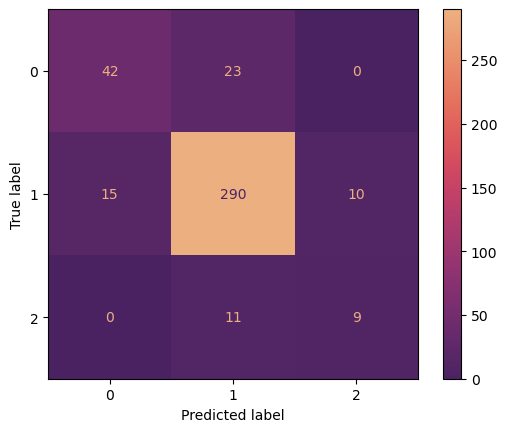

In [61]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_SM, cmap="flare_r")

### 5.1.2 Tuned Model

In [62]:
best_model.fit(X_smote, y_smote) 

,n_estimators,500
,criterion,'entropy'
,max_depth,30
,min_samples_split,5
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
y_pred_best_SM = best_model.predict(X_test)

In [64]:
print("Classification Report for Tuned Model - SMOTE:")
print(classification_report(y_test, y_pred_best_SM))

Classification Report for Tuned Model - SMOTE:
              precision    recall  f1-score   support

           0       0.73      0.69      0.71        65
           1       0.91      0.89      0.90       315
           2       0.39      0.60      0.47        20

    accuracy                           0.84       400
   macro avg       0.67      0.73      0.69       400
weighted avg       0.85      0.84      0.85       400



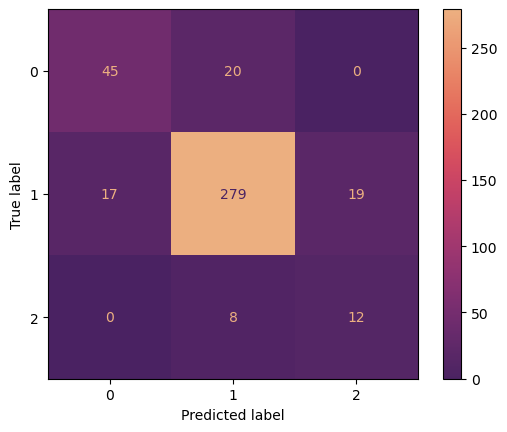

In [65]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_SM, cmap="flare_r")

### 5.1.1 Balanced Model

In [66]:
balanced_model.fit(X_smote, y_smote) 

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [67]:
y_pred_balanced_SM = balanced_model.predict(X_test)

In [68]:
print("Classification Report for Balanced Model - SMOTE:")
print(classification_report(y_test, y_pred_balanced_SM))

Classification Report for Balanced Model - SMOTE:
              precision    recall  f1-score   support

           0       0.74      0.66      0.70        65
           1       0.90      0.92      0.91       315
           2       0.45      0.45      0.45        20

    accuracy                           0.85       400
   macro avg       0.70      0.68      0.69       400
weighted avg       0.85      0.85      0.85       400



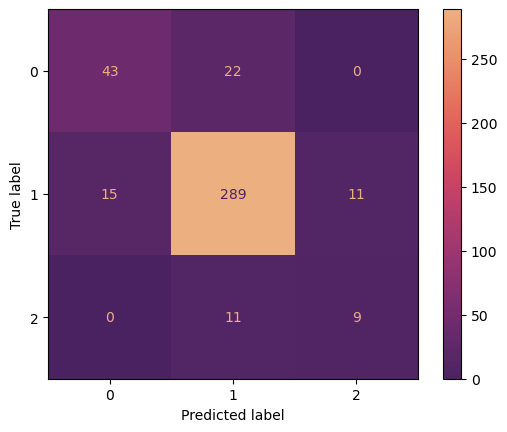

In [69]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced_SM, cmap="flare_r")

---
# Reference List